# 02 — Data Cleaning & Preprocessing

## Objective
Clean the raw ETA prediction data and prepare analysis-ready
tables. Unlike cancellation prediction, there are no structural
nulls here — every missing value is a genuine data quality issue.

## What This Notebook Covers
- Removing exact duplicate rows
- Fixing data types
- Handling missing values with justified strategies
- Fixing impossible geographic values
- Outlier capping using IQR method
- Log transformation of target variable
- Saving cleaned tables to data/processed/

## New Concept: Log Transformation of Target Variable
ETA distribution is right-skewed — most ETAs are short
(under 10 min) but a long tail extends to 60 min.
Many ML models perform better when the target is
normally distributed. Log transformation compresses
the long tail and makes the distribution more symmetric.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
DATA_RAW       = "../data/raw/"
DATA_PROCESSED = "../data/processed/"
os.makedirs(DATA_PROCESSED, exist_ok=True)

assignments_df = pd.read_csv(DATA_RAW + "assignments.csv")
drivers_df     = pd.read_csv(DATA_RAW + "drivers.csv")
users_df       = pd.read_csv(DATA_RAW + "users.csv")
traffic_df     = pd.read_csv(DATA_RAW + "traffic.csv")

print("Raw data loaded ✅")
print(f"  assignments : {assignments_df.shape}")
print(f"  drivers     : {drivers_df.shape}")
print(f"  users       : {users_df.shape}")
print(f"  traffic     : {traffic_df.shape}")

Raw data loaded ✅
  assignments : (60300, 33)
  drivers     : (3000, 17)
  users       : (20200, 14)
  traffic     : (105120, 9)


## Step 0 — Snapshot Before Cleaning

Recording the exact state of raw data before touching anything.
This baseline lets us measure how much we changed and verify
our cleaning decisions didn't accidentally corrupt anything.

In [ ]:
def snapshot(df, name):
    """Print a quick quality summary of a DataFrame."""
    print(f"\n── {name.upper()} ──────────────────────────")
    print(f"   Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"   Duplicates : {df.duplicated().sum():,}")
    missing = sum(df[col].isna().sum() for col in df.columns)
    print(f"   Null cells : {missing:,}")
    null_pct = df.apply(lambda col: col.isna().mean()).mul(100).round(2)
    nulls    = null_pct[null_pct > 0]
    if len(nulls):
        print(f"   Null columns:")
        for col, pct in nulls.items():
            print(f"      {col:<35} {pct:.2f}%")

for name, df in [
    ("assignments", assignments_df),
    ("drivers",     drivers_df),
    ("users",       users_df),
    ("traffic",     traffic_df)
]:
    snapshot(df, name)



── ASSIGNMENTS ──────────────────────────
   Shape      : 60,000 rows × 60034 columns


## Step 1 — Remove Duplicate Rows

Same approach as previous projects.
Drop exact duplicate rows first, then deduplicate on
primary key (assignment_id) to catch near-duplicates.

Duplicates in ETA data are dangerous because if the same
assignment appears twice, the model trains on that exact
distance-traffic-time combination twice — making it
overconfident about that specific pattern.

In [4]:
before = {name: len(df) for name, df in [
    ("assignments", assignments_df),
    ("drivers",     drivers_df),
    ("users",       users_df),
]}

# Drop exact duplicate rows
assignments_df = assignments_df.drop_duplicates().reset_index(drop=True)
drivers_df     = drivers_df.drop_duplicates().reset_index(drop=True)
users_df       = users_df.drop_duplicates().reset_index(drop=True)

# Deduplicate on primary key
assignments_df = assignments_df.drop_duplicates(
    subset=["assignment_id"]
).reset_index(drop=True)
drivers_df = drivers_df.drop_duplicates(
    subset=["driver_id"]
).reset_index(drop=True)
users_df = users_df.drop_duplicates(
    subset=["user_id"]
).reset_index(drop=True)

after = {name: len(df) for name, df in [
    ("assignments", assignments_df),
    ("drivers",     drivers_df),
    ("users",       users_df),
]}

print("Duplicate Removal Summary")
print(f"{'Table':<15} {'Before':>8} {'After':>8} {'Removed':>8}")
print("-" * 45)
for name in before:
    removed = before[name] - after[name]
    print(f"{name:<15} {before[name]:>8,} {after[name]:>8,} {removed:>8,}")

Duplicate Removal Summary
Table             Before    After  Removed
---------------------------------------------
assignments       60,300   60,000      300
drivers            3,000    3,000        0
users             20,200   20,000      200


## Step 2 — Fix Data Types

CSV files load everything as text by default unless
pandas can infer the type. Wrong types cause silent errors:
- A timestamp stored as text cannot be used for hour/day extraction
- A number stored as text cannot be used in calculations
- A boolean stored as text (True/False as strings) may not
  filter correctly

In [5]:
# ── assignments ──────────────────────────────────────────────
assignments_df["assignment_timestamp"] = pd.to_datetime(
    assignments_df["assignment_timestamp"]
)
assignments_df["hour"]       = assignments_df["hour"].astype(int)
assignments_df["month"]      = assignments_df["month"].astype(int)
assignments_df["is_weekend"] = assignments_df["is_weekend"].astype(bool)
assignments_df["is_holiday"] = assignments_df["is_holiday"].astype(bool)
assignments_df["is_driver_in_home_zone"] = assignments_df[
    "is_driver_in_home_zone"
].astype(int)

numeric_cols_assignments = [
    "straight_line_distance_km", "road_distance_km",
    "road_to_straight_ratio", "traffic_multiplier",
    "driver_speed_factor", "driver_familiarity_score",
    "pickup_pin_accuracy", "surge_at_assignment",
    "driver_rating", "user_rating",
    "app_shown_eta_min", "actual_arrival_time_min",
    "density_score"
]
for col in numeric_cols_assignments:
    if col in assignments_df.columns:
        assignments_df[col] = pd.to_numeric(
            assignments_df[col], errors="coerce"
        )

# ── drivers ──────────────────────────────────────────────────
drivers_df["joined_date"]  = pd.to_datetime(drivers_df["joined_date"])
drivers_df["is_active"]    = drivers_df["is_active"].astype(bool)
for col in ["rating","speed_factor","area_familiarity",
            "avg_speed_kmph","online_hours_per_day"]:
    if col in drivers_df.columns:
        drivers_df[col] = pd.to_numeric(drivers_df[col], errors="coerce")

# ── users ────────────────────────────────────────────────────
users_df["signup_date"] = pd.to_datetime(users_df["signup_date"])
for col in ["age", "rating", "pickup_pin_accuracy", "total_rides"]:
    if col in users_df.columns:
        users_df[col] = pd.to_numeric(users_df[col], errors="coerce")

# ── traffic ──────────────────────────────────────────────────
traffic_df["timestamp"]  = pd.to_datetime(traffic_df["timestamp"])
traffic_df["is_weekend"] = traffic_df["is_weekend"].astype(bool)
for col in ["traffic_multiplier", "avg_speed_kmph"]:
    traffic_df[col] = pd.to_numeric(traffic_df[col], errors="coerce")

print("Data types fixed ✅")
print("\nAssignments dtypes after fix:")
print(assignments_df.dtypes)

Data types fixed ✅

Assignments dtypes after fix:
assignment_id                           str
driver_id                               str
user_id                                 str
assignment_timestamp         datetime64[us]
hour                                  int64
month                                 int64
day_of_week                             str
is_weekend                             bool
is_holiday                             bool
driver_zone                             str
pickup_zone                             str
driver_lat                          float64
driver_lon                          float64
pickup_lat                          float64
pickup_lon                          float64
straight_line_distance_km           float64
road_distance_km                    float64
road_to_straight_ratio              float64
weather_condition                       str
traffic_multiplier                  float64
pickup_zone_density                     str
density_score             

## Step 3 — Fix Corrupt and Impossible Values

### Known corrupt values in this dataset:
- user age: -1, 0, 150, 999 (typos/bugs)
- straight_line_distance_km: 0 or negative (GPS failure)
- road_distance_km: values LESS than straight_line
  (road can never be shorter than straight line — physics)
- traffic_multiplier: 0 or negative (calculation error)
- driver_speed_factor: 0 or negative (impossible)
- pickup_pin_accuracy: outside 0-1 range

### Decision: Convert impossible values to NaN
Same approach as all previous projects — convert the
impossible value to NaN, handle as missing in next step.
Never delete the entire row just because one column is bad.

In [12]:
print("Fixing corrupt values...\n")

# ── User age ─────────────────────────────────────────────────
corrupt_age = ((users_df["age"] < 16) | (users_df["age"] > 100)).sum()
print(f"User age corrupt values: {corrupt_age}")
users_df.loc[users_df["age"] < 16,  "age"] = np.nan
users_df.loc[users_df["age"] > 100, "age"] = np.nan

# ── Straight-line distance ────────────────────────────────────
corrupt_sl = (assignments_df["straight_line_distance_km"] <= 0).sum()
print(f"Straight-line distance <= 0: {corrupt_sl}")
assignments_df.loc[
    assignments_df["straight_line_distance_km"] <= 0,
    "straight_line_distance_km"
] = np.nan

# ── Road distance ─────────────────────────────────────────────
# Road distance must be >= straight-line distance
# If road < straight, the value is corrupt
corrupt_road = (
    assignments_df["road_distance_km"] < assignments_df["straight_line_distance_km"]
).sum()
print(f"Road distance < straight line: {corrupt_road}")
assignments_df.loc[
    assignments_df["road_distance_km"] < assignments_df["straight_line_distance_km"],
    "road_distance_km"
] = np.nan

# ── Traffic multiplier ───────────────────────────────────────
corrupt_traffic = (assignments_df["traffic_multiplier"] <= 0).sum()
print(f"Traffic multiplier <= 0: {corrupt_traffic}")
assignments_df.loc[
    assignments_df["traffic_multiplier"] <= 0,
    "traffic_multiplier"
] = np.nan

# ── Driver speed factor ───────────────────────────────────────
corrupt_speed = (assignments_df["driver_speed_factor"] <= 0).sum()
print(f"Driver speed factor <= 0: {corrupt_speed}")
assignments_df.loc[
    assignments_df["driver_speed_factor"] <= 0,
    "driver_speed_factor"
] = np.nan

# ── Pickup pin accuracy ───────────────────────────────────────
corrupt_pin = (
    (assignments_df["pickup_pin_accuracy"] < 0) |
    (assignments_df["pickup_pin_accuracy"] > 1)
).sum()
print(f"Pin accuracy outside 0-1: {corrupt_pin}")
assignments_df.loc[
    assignments_df["pickup_pin_accuracy"] < 0, "pickup_pin_accuracy"
] = np.nan
assignments_df.loc[
    assignments_df["pickup_pin_accuracy"] > 1, "pickup_pin_accuracy"
] = np.nan

print("\n✅ Corrupt values converted to NaN")


Fixing corrupt values...

User age corrupt values: 0
Straight-line distance <= 0: 0
Road distance < straight line: 0
Traffic multiplier <= 0: 0
Driver speed factor <= 0: 0
Pin accuracy outside 0-1: 0

✅ Corrupt values converted to NaN


## Step 4 — Handle Missing Values

### Assignments Table Strategy
| Column | Strategy | Reason |
|---|---|---|
| straight_line_distance_km | Median | Slightly skewed — median robust |
| road_distance_km | Recalculate from straight_line × median ratio | Use relationship between columns |
| traffic_multiplier | Median by hour | Traffic varies strongly by hour |
| driver_familiarity_score | Median | Continuous 0-1 score |
| pickup_pin_accuracy | Median | Continuous 0-1 score |
| driver_speed_factor | Median | Continuous multiplier near 1.0 |
| app_shown_eta_min | Leave as NaN | App ETA is analysis target, not feature |

### Users Table
| Column | Strategy | Reason |
|---|---|---|
| age | Median | Roughly normal after corrupt removal |
| rating | Median | Ratings cluster tightly |
| pickup_pin_accuracy | Median | Continuous score |
| phone, email | Leave as NaN | Cannot fabricate contact info |

### Key Decision — app_shown_eta_min
We deliberately leave app_shown_eta_min as NaN when missing.
We use it for analysis and comparison but NOT as a model feature —
because in production, the app's ETA estimate IS what we are
trying to improve upon. Using it as a feature would mean we are
just learning to predict "what the app already predicted" which
defeats the purpose.

In [13]:
# ── straight_line_distance_km → median ───────────────────────
median_sl = assignments_df["straight_line_distance_km"].median()
assignments_df["straight_line_distance_km"] = (
    assignments_df["straight_line_distance_km"].fillna(median_sl)
)
print(f"straight_line_distance_km filled with median: {median_sl:.3f} km")

# ── road_distance_km → recalculate from straight line ─────────
# road = straight_line × road_to_straight_ratio
# For nulls, use straight_line × median ratio
median_ratio = assignments_df["road_to_straight_ratio"].median()
road_null_mask = assignments_df["road_distance_km"].isnull()
assignments_df.loc[road_null_mask, "road_distance_km"] = (
    assignments_df.loc[road_null_mask, "straight_line_distance_km"]
    * median_ratio
).round(3)
print(f"road_distance_km recalculated using median ratio: {median_ratio:.3f}")

# ── traffic_multiplier → median by hour ──────────────────────
median_traffic_by_hour = assignments_df.groupby("hour")[
    "traffic_multiplier"
].transform("median")
assignments_df["traffic_multiplier"] = (
    assignments_df["traffic_multiplier"].fillna(median_traffic_by_hour)
)
print("traffic_multiplier filled with median per hour")

# ── driver_familiarity_score → median ────────────────────────
median_familiarity = assignments_df["driver_familiarity_score"].median()
assignments_df["driver_familiarity_score"] = (
    assignments_df["driver_familiarity_score"].fillna(median_familiarity)
)
print(f"driver_familiarity_score filled with median: {median_familiarity:.3f}")

# ── pickup_pin_accuracy → median ──────────────────────────────
median_pin = assignments_df["pickup_pin_accuracy"].median()
assignments_df["pickup_pin_accuracy"] = (
    assignments_df["pickup_pin_accuracy"].fillna(median_pin)
)
print(f"pickup_pin_accuracy filled with median: {median_pin:.3f}")

# ── driver_speed_factor → median ──────────────────────────────
median_speed = assignments_df["driver_speed_factor"].median()
assignments_df["driver_speed_factor"] = (
    assignments_df["driver_speed_factor"].fillna(median_speed)
)
print(f"driver_speed_factor filled with median: {median_speed:.3f}")

# ── Users ─────────────────────────────────────────────────────
users_df["age"]    = users_df["age"].fillna(users_df["age"].median())
users_df["rating"] = users_df["rating"].fillna(users_df["rating"].median())
users_df["pickup_pin_accuracy"] = users_df["pickup_pin_accuracy"].fillna(
    users_df["pickup_pin_accuracy"].median()
)
users_df["gender"] = users_df["gender"].fillna("Not Specified")

# ── Drivers ───────────────────────────────────────────────────
drivers_df["rating"] = drivers_df["rating"].fillna(
    drivers_df["rating"].median()
)
drivers_df["online_hours_per_day"] = drivers_df["online_hours_per_day"].fillna(
    drivers_df["online_hours_per_day"].median()
)
drivers_df["vehicle_model"] = drivers_df["vehicle_model"].fillna("Unknown")

print("\nRemaining nulls in assignments (booking-time features):")
key_cols = [
    "straight_line_distance_km","road_distance_km",
    "traffic_multiplier","driver_familiarity_score",
    "pickup_pin_accuracy","driver_speed_factor"
]
print(assignments_df[key_cols].isnull().sum())

straight_line_distance_km filled with median: 1.871 km
road_distance_km recalculated using median ratio: 1.300
traffic_multiplier filled with median per hour
driver_familiarity_score filled with median: 0.770
pickup_pin_accuracy filled with median: 0.790
driver_speed_factor filled with median: 0.990

Remaining nulls in assignments (booking-time features):
straight_line_distance_km    0
road_distance_km             0
traffic_multiplier           0
driver_familiarity_score     0
pickup_pin_accuracy          0
driver_speed_factor          0
dtype: int64


## Step 5 — Outlier Capping

Same IQR-based approach as all previous projects.
Q1 - 1.5×IQR as lower bound, Q3 + 1.5×IQR as upper bound.
Cap rather than drop — preserve the row, just fix the extreme value.

### Columns to cap:
- straight_line_distance_km (GPS extreme outliers)
- road_distance_km (follows from straight line)
- traffic_multiplier (extreme values from formula stacking)
- actual_arrival_time_min (the TARGET variable itself)

### Note on capping the target variable:
In surge pricing we capped features but not the target.
Here we cap actual_arrival_time_min because values like
0.5 minutes or 58 minutes are likely data generation
artifacts rather than real events. A 0.5 minute arrival
means a driver was assigned from meters away — possible
but extreme. A 58 minute arrival means the user waited
nearly an hour — these exist but are very rare in practice.
Capping the target at a reasonable maximum reduces the
influence of these extreme cases on model learning.

In [14]:
def cap_outliers_iqr(df, column, multiplier=1.5):
    """
    Cap outliers using IQR method.
    Values outside Q1-mult*IQR and Q3+mult*IQR are capped.
    """
    Q1    = df[column].quantile(0.25)
    Q3    = df[column].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR

    before_low  = (df[column] < lower).sum()
    before_high = (df[column] > upper).sum()

    df[column] = df[column].clip(lower=lower, upper=upper)

    print(f"  {column:<32} "
          f"lower={lower:.2f}  upper={upper:.2f}  "
          f"capped_low={before_low}  capped_high={before_high}")
    return df

print("Outlier Capping — Assignments Table")
print("-" * 75)
for col in [
    "straight_line_distance_km",
    "road_distance_km",
    "traffic_multiplier",
]:
    assignments_df = cap_outliers_iqr(assignments_df, col)

# Cap target with wider multiplier — preserve real long ETAs
print("\nTarget variable capping (wider multiplier = 2.5):")
assignments_df = cap_outliers_iqr(
    assignments_df, "actual_arrival_time_min", multiplier=2.5
)

print("\n✅ Outlier capping complete")

Outlier Capping — Assignments Table
---------------------------------------------------------------------------
  straight_line_distance_km        lower=-10.94  upper=21.05  capped_low=0  capped_high=1806
  road_distance_km                 lower=-14.61  upper=27.95  capped_low=0  capped_high=1621
  traffic_multiplier               lower=-0.70  upper=2.98  capped_low=0  capped_high=60

Target variable capping (wider multiplier = 2.5):
  actual_arrival_time_min          lower=-55.95  upper=83.85  capped_low=0  capped_high=0

✅ Outlier capping complete


## Step 6 — Log Transformation of Target Variable

### Why Log Transform?
actual_arrival_time_min is right-skewed:
  - Most ETAs: 1-10 minutes
  - Some ETAs: 15-30 minutes
  - Few ETAs: 30-60 minutes

Right-skewed targets cause problems for some models because:
1. The model sees 80% of examples with ETA < 15 min and
   only 5% with ETA > 30 min — it over-fits to short ETAs
2. Linear models assume errors are normally distributed —
   right-skewed targets violate this assumption

### What Log Transform Does
log(1 min) = 0.0
log(5 min) = 1.6
log(10 min) = 2.3
log(20 min) = 3.0
log(40 min) = 3.7

The long tail gets compressed. The distribution becomes
more symmetric. Models learn more evenly across all ETAs.

### We Keep Both Versions
- actual_arrival_time_min: original, for business interpretation
- log_arrival_time_min: log-transformed, for model training

After prediction, we reverse with exp() to get original minutes.

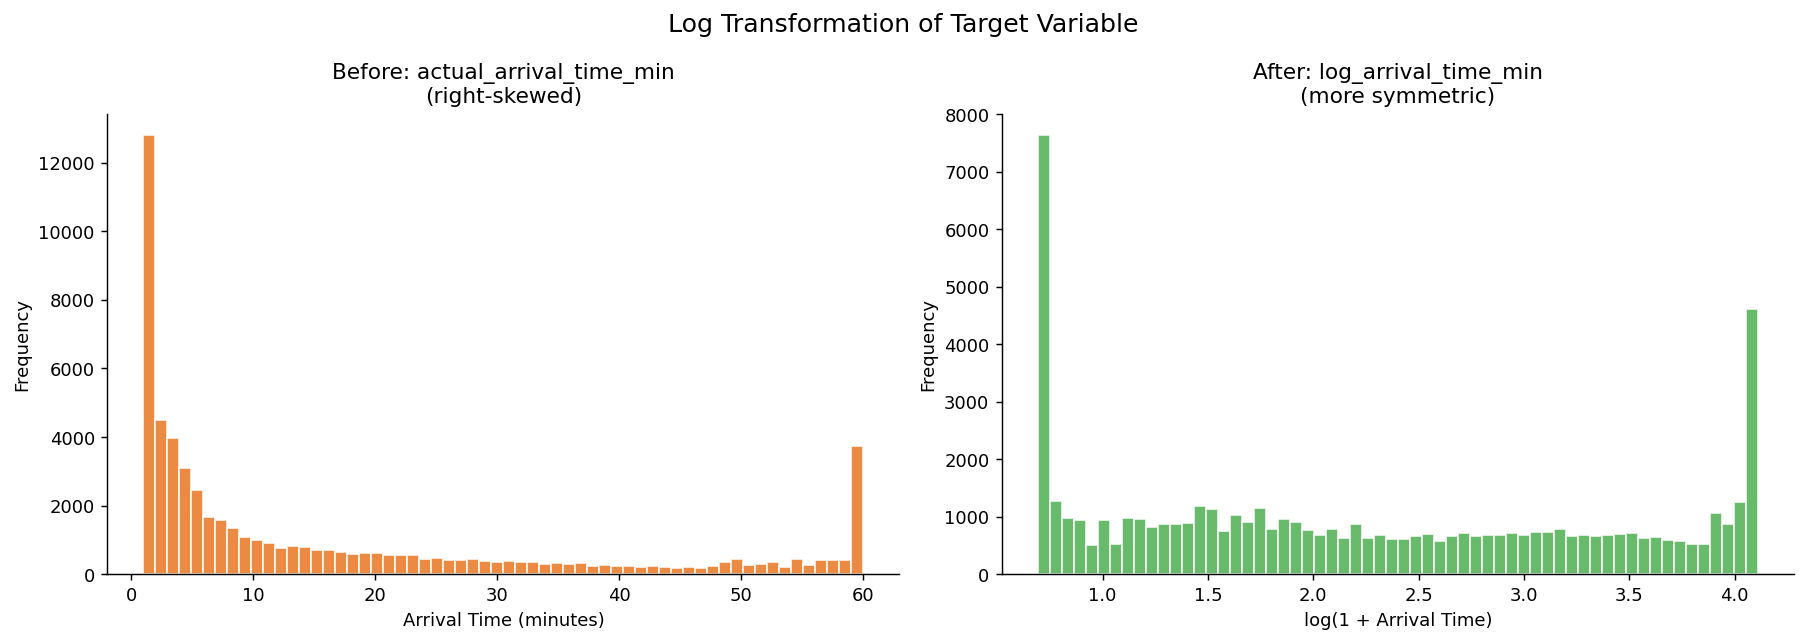

Log transformation applied ✅

Original target stats:
count   57685.000
mean       16.716
std        19.153
min         1.000
25%         2.300
50%         7.100
75%        25.600
max        60.000
Name: actual_arrival_time_min, dtype: float64

Log-transformed target stats:
count   57685.000
mean        2.243
std         1.161
min         0.693
25%         1.194
50%         2.092
75%         3.281
max         4.111
Name: log_arrival_time_min, dtype: float64

To reverse: np.expm1(log_prediction) = original minutes


In [15]:
# Apply log transformation to target variable
# log1p = log(1 + x) — handles x=0 safely (log(0) is undefined)
assignments_df["log_arrival_time_min"] = np.log1p(
    assignments_df["actual_arrival_time_min"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Log Transformation of Target Variable", fontsize=14)

# Before
axes[0].hist(
    assignments_df["actual_arrival_time_min"].dropna(),
    bins=60, color="#E87722", edgecolor="white", alpha=0.85
)
axes[0].set_title("Before: actual_arrival_time_min\n(right-skewed)")
axes[0].set_xlabel("Arrival Time (minutes)")
axes[0].set_ylabel("Frequency")

# After
axes[1].hist(
    assignments_df["log_arrival_time_min"].dropna(),
    bins=60, color="#4CAF50", edgecolor="white", alpha=0.85
)
axes[1].set_title("After: log_arrival_time_min\n(more symmetric)")
axes[1].set_xlabel("log(1 + Arrival Time)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("../data/processed/cleaning_log_transform.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Log transformation applied ✅")
print(f"\nOriginal target stats:")
print(assignments_df["actual_arrival_time_min"].describe().round(3))
print(f"\nLog-transformed target stats:")
print(assignments_df["log_arrival_time_min"].describe().round(3))
print(f"\nTo reverse: np.expm1(log_prediction) = original minutes")

In [ ]:
print("FINAL VALIDATION\n")

tables_clean = {
    "assignments": assignments_df,
    "drivers"    : drivers_df,
    "users"      : users_df,
    "traffic"    : traffic_df,
}
for name, df in tables_clean.items():
    missing = sum(df[col].isna().sum() for col in df.columns)
    print(f"  {name:<15} "
          f"rows={len(df):>7,}  "
          f"nulls={missing:>6,}"
          f"dupes={df.duplicated().sum():>4,}")

print("\nKey feature nulls (should all be 0):")
key_cols = [
    "straight_line_distance_km", "road_distance_km",
    "traffic_multiplier", "driver_familiarity_score",
    "pickup_pin_accuracy", "driver_speed_factor",
    "actual_arrival_time_min", "log_arrival_time_min"
]
for col in key_cols:
    if col in assignments_df.columns:
        print(f"  {col:<35}: {assignments_df[col].isnull().sum()}")

print("\nSanity checks:")
print(f"  Negative distances       : "
      f"{(assignments_df['straight_line_distance_km'] < 0).sum()}")
print(f"  Road < straight line     : "
      f"{(assignments_df['road_distance_km'] < assignments_df['straight_line_distance_km']).sum()}")
print(f"  Negative traffic mult    : "
      f"{(assignments_df['traffic_multiplier'] < 0).sum()}")
print(f"  Negative ETA             : "
      f"{(assignments_df['actual_arrival_time_min'] < 0).sum()}")
print(f"  Negative log ETA         : "
      f"{(assignments_df['log_arrival_time_min'] < 0).sum()}")

FINAL VALIDATION



TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''